# Log Anomaly Detection

## Phase 5: Modeling

This phase implements the comparative study fixed in the project's original methodological decisions: a bag-of-events (template count vector) baseline paired with a classical classifier, against a sequence LSTM that preserves template order, with the explicit goal of establishing whether order information provides a measurable improvement over the baseline. Both models are fit and validated using train and validation data only; `data/interim/hdfs_parsed_events.csv`'s and `data/processed/boe_features.csv`'s/`sequence_features.jsonl`'s test-split rows are never loaded in this notebook. `06_sealed_evaluation.ipynb` is the only place either model is scored against test.

Four constraints carry forward from Phase 4 and govern this notebook:

1. **Train-only fitting.** Any scaler, encoder, class-imbalance handling strategy, or model parameter fit in this notebook is fit on `boe_train.csv` / `sequence_train.jsonl` only, and applied as a frozen transform to validation, following the same fitting discipline used for the Drain dictionary in Phase 2. Validation is for model selection and comparison, not for fitting anything.
2. **`is_anomaly` and `is_truncated` are both present in every labeled artifact.** `is_anomaly` is the target. `is_truncated` is not automatically a feature; whether to include it as a model input, use it only for stratified reporting, or both, is a decision this notebook must make explicitly and record, not inherit silently from Phase 4's neutrality on the question.
3. **Class imbalance is real and must be handled deliberately.** `03_eda.ipynb` Section 3.2 established a train+val anomaly rate of roughly 3.2%, itself already lower than what the model will face at inference relative to training (the implied test rate is approximately 1.29%, per the same section). Whatever imbalance-handling strategy is chosen (class weighting, resampling, threshold adjustment, or a combination) must be fit or tuned on train/validation only and documented with justification.
4. **No sealed metric is computed or previewed here.** This notebook reports validation metrics only. A model's validation performance is not a stand-in for its test performance, particularly given the class-balance drift in point 3; this notebook must not speculate about expected test performance beyond what Section 3.2 already established structurally.

The seven sub-sections performed here are: loading the labeled train/validation artifacts, establishing an evaluation protocol shared by both models, fitting and tuning the bag-of-events baseline, fitting and tuning the sequence LSTM, a head-to-head comparison on validation, an error analysis cross-referencing Phase 3/4 findings, and a phase summary.

### 5.1 Load Labeled Train/Validation Artifacts

This section loads only the artifacts Phase 4 explicitly produced for modeling: `boe_train.csv`, `boe_val.csv`, `sequence_train.jsonl`, and `sequence_val.jsonl`. The full, unlabeled, all-splits artifacts (`boe_features.csv`, `sequence_features.jsonl`) are not loaded here; there is no need to filter them down, since Phase 4 already did that filtering once and persisted the result.

In [1]:
import json
import yaml
import pandas as pd
from pathlib import Path

# 1. Resolve root and load SSOT configuration
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

RANDOM_STATE = config["reproducibility"]["random_state"]
DEVICE = config["hardware"]["device"].lower()
PROCESSED_DIR = PROJECT_ROOT / config["paths"]["processed_dir"]

BOE_TRAIN_PATH = PROCESSED_DIR / "boe_train.csv"
BOE_VAL_PATH = PROCESSED_DIR / "boe_val.csv"
SEQ_TRAIN_PATH = PROCESSED_DIR / "sequence_train.jsonl"
SEQ_VAL_PATH = PROCESSED_DIR / "sequence_val.jsonl"

print(f"Device policy from config : '{DEVICE}'")
assert DEVICE == "cpu", f"Device policy violation: expected 'cpu', got '{DEVICE}'"

# 2. Load Bag-of-Events labeled artifacts
assert BOE_TRAIN_PATH.exists(), f"Missing BoE train artifact at {BOE_TRAIN_PATH}"
assert BOE_VAL_PATH.exists(), f"Missing BoE val artifact at {BOE_VAL_PATH}"

df_boe_train = pd.read_csv(BOE_TRAIN_PATH)
df_boe_val = pd.read_csv(BOE_VAL_PATH)

print("\n--- Bag-of-Events Artifact Audit ---")
print(f"Train BoE rows : {len(df_boe_train):,} (Columns: {df_boe_train.shape[1]})")
print(f"Val BoE rows   : {len(df_boe_val):,} (Columns: {df_boe_val.shape[1]})")

assert len(df_boe_train) == 402_543, "BoE train row count mismatch!"
assert len(df_boe_val) == 86_259, "BoE val row count mismatch!"
assert not df_boe_train["is_anomaly"].isna().any(), "Missing targets in BoE train!"
assert not df_boe_val["is_anomaly"].isna().any(), "Missing targets in BoE val!"
assert "is_truncated" in df_boe_train.columns, "is_truncated column missing in BoE train!"

# 3. Load Sequence artifacts and verify block_id parity
assert SEQ_TRAIN_PATH.exists(), f"Missing Sequence train artifact at {SEQ_TRAIN_PATH}"
assert SEQ_VAL_PATH.exists(), f"Missing Sequence val artifact at {SEQ_VAL_PATH}"

print("\nLoading Sequence artifacts (JSON Lines)...")
records_seq_train = []
with open(SEQ_TRAIN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        records_seq_train.append(json.loads(line))

records_seq_val = []
with open(SEQ_VAL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        records_seq_val.append(json.loads(line))

print(f"Train Sequence records : {len(records_seq_train):,}")
print(f"Val Sequence records   : {len(records_seq_val):,}")

assert len(records_seq_train) == 402_543, "Sequence train record count mismatch!"
assert len(records_seq_val) == 86_259, "Sequence val record count mismatch!"

# Verify strict 1-to-1 block_id alignment
seq_train_blocks = [r["block_id"] for r in records_seq_train]
seq_val_blocks = [r["block_id"] for r in records_seq_val]

assert (df_boe_train["block_id"] == seq_train_blocks).all(), "Train representation block_id alignment failure!"
assert (df_boe_val["block_id"] == seq_val_blocks).all(), "Val representation block_id alignment failure!"
print("Representation parity check : PASS (100% exact block alignment between BoE and Sequence).")

# 4. Class balance check against Phase 3
train_anom_rate = df_boe_train["is_anomaly"].mean() * 100
val_anom_rate = df_boe_val["is_anomaly"].mean() * 100

print("\n--- Loaded Class Balance Audit ---")
print(f"Train anomaly rate : {train_anom_rate:.4f}% ({df_boe_train['is_anomaly'].sum():,} / {len(df_boe_train):,})")
print(f"Val anomaly rate   : {val_anom_rate:.4f}% ({df_boe_val['is_anomaly'].sum():,} / {len(df_boe_val):,})")

assert abs(train_anom_rate - 3.2580) < 1e-3, "Train class balance drift from Phase 3!"
assert abs(val_anom_rate - 3.0223) < 1e-3, "Val class balance drift from Phase 3!"
print("Class balance parity check  : PASS (Exact match with Phase 3 Section 3.2).")

Device policy from config : 'cpu'

--- Bag-of-Events Artifact Audit ---
Train BoE rows : 402,543 (Columns: 54)
Val BoE rows   : 86,259 (Columns: 54)

Loading Sequence artifacts (JSON Lines)...
Train Sequence records : 402,543
Val Sequence records   : 86,259
Representation parity check : PASS (100% exact block alignment between BoE and Sequence).

--- Loaded Class Balance Audit ---
Train anomaly rate : 3.2580% (13,115 / 402,543)
Val anomaly rate   : 3.0223% (2,607 / 86,259)
Class balance parity check  : PASS (Exact match with Phase 3 Section 3.2).


**Findings 5.1:**

Both labeled representations loaded successfully with row counts matching the
Phase 1 block-count partition exactly (402,543 train, 86,259 validation). The
bag-of-events artifacts carry 54 columns (the 53 established in Phase 4 plus
`is_anomaly`), and both `is_anomaly` and `is_truncated` are present with zero
missing values. Strict positional block_id alignment between the bag-of-events
and sequence representations passed for both train and validation, confirming
the two representations describe the same blocks in the same order. The loaded
class balance matches `03_eda.ipynb` Section 3.2 exactly (3.2580% train,
3.0223% val), confirming no drift was introduced between Phase 3's measurement
and Phase 4/5's persisted artifacts. The device policy check confirmed `cpu` as
configured.

### 5.2 Evaluation Protocol

This section fixes, before either model is fit, the metrics and comparison procedure both models will be judged by, so that neither model's evaluation can be adjusted after the fact to flatter its own result. Given the class imbalance established in Section 5.1, accuracy alone is not an adequate metric; precision, recall, F1, and a precision-recall curve (more informative than ROC under this imbalance) are the minimum required set. Because `is_truncated` was flagged in Phase 4 rather than excluded, validation metrics must also be reported stratified by `is_truncated`, to make visible whether either model performs differently on partial, boundary-truncated sequences versus complete ones — this stratified view is part of the protocol, not an optional afterthought.

**Decision 5.2: Modeling Evaluation Protocol**

1. **Primary Metric:** **PR-AUC (Average Precision Score)** is the primary metric for model comparison. Because anomalies constitute only ~3% of the data, PR-AUC evaluates ranking quality across all thresholds without being distorted by true negatives.
2. **Operational Decision Metric:** The **Best-F1** score on validation, along with its optimal threshold, Precision, and Recall, is reported to reflect operational performance.
3. **Role of `is_truncated`:**
   - Included as an explicit model feature (`is_truncated`) in both representations.
   - Used as an independent stratification axis: validation metrics are reported across the entire validation set, for non-truncated blocks (`is_truncated == 0`), and for truncated blocks (`is_truncated == 1`).
4. **Class Imbalance Handling:**
   - Classical Model: Cost-sensitive balanced class weighting (`class_weight='balanced'`).
   - LSTM: Weighted Binary Cross-Entropy with Logits using `pos_weight = (N_neg / N_pos) ≈ 29.7` computed strictly on train.
5. **Threshold Persistence:** The best-F1 threshold selected on validation in
   Sections 5.3 and 5.4 is persisted as a frozen artifact (per model) and
   reused as-is in `06_sealed_evaluation.ipynb`. It is never re-derived on
   test data — doing so would leak tuning information from the sealed set and
   would not reflect a deployable system, which cannot retune its decision
   threshold using future, unseen labels.

In [2]:
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, f1_score, precision_score, recall_score

def evaluate_predictions(y_true, y_probs, threshold=None):
    """
    Computes threshold-independent metrics (PR-AUC, ROC-AUC) and finds
    optimal threshold maximizing F1 if threshold is not provided.
    """
    pr_auc = average_precision_score(y_true, y_probs)
    roc_auc = roc_auc_score(y_true, y_probs)
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    if threshold is None:
        # Find threshold maximizing F1
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    else:
        best_threshold = threshold
        
    y_pred = (y_probs >= best_threshold).astype(int)
    
    return {
        "pr_auc": float(pr_auc),
        "roc_auc": float(roc_auc),
        "best_threshold": float(best_threshold),
        "best_f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0))
    }

def print_stratified_metrics(name, y_true, y_probs, is_truncated, threshold=None):
    """Prints evaluation breakdown overall, non-truncated, and truncated.
    
    The decision threshold is selected once, by maximizing F1 on the overall
    validation set, and then reused unchanged for both the truncated and
    non-truncated subsets. Thresholds are deliberately not re-optimized per
    subset: a real deployment has a single operating threshold, and
    re-tuning per stratum would report an inflated, non-deployable metric
    for each slice rather than the actual behavior of one fixed model.
    """
    overall = evaluate_predictions(y_true, y_probs, threshold)
    t = overall["best_threshold"]
    
    mask_non_trunc = (is_truncated == 0)
    mask_trunc = (is_truncated == 1)
    
    non_trunc = evaluate_predictions(y_true[mask_non_trunc], y_probs[mask_non_trunc], threshold=t)
    trunc = evaluate_predictions(y_true[mask_trunc], y_probs[mask_trunc], threshold=t)
    
    print(f"\n--- Validation Performance: {name} ---")
    print(f"{'Slice':<16} | {'PR-AUC':<8} | {'Best-F1':<8} | {'Precision':<10} | {'Recall':<8} | {'ROC-AUC':<8}")
    print("-" * 68)
    for slice_name, res in [("Overall", overall), ("Non-Truncated", non_trunc), ("Truncated", trunc)]:
        print(f"{slice_name:<16} | {res['pr_auc']:.4f}   | {res['best_f1']:.4f}   | "
              f"{res['precision']:.4f}     | {res['recall']:.4f}   | {res['roc_auc']:.4f}")
    print(f"(Optimal decision threshold: {t:.4f})")
    
    return overall, non_trunc, trunc

### 5.3 Baseline: Bag-of-Events Classifier

This section fits the classical baseline on `boe_train.csv`. Any preprocessing this classifier requires (scaling, class weighting) is fit on train only and applied to validation as a frozen transform. The specific classifier family is an open choice (for example, logistic regression as an interpretable linear baseline, or a tree-based ensemble as a stronger but less directly interpretable baseline); whichever is chosen, feature importances or coefficients should be inspected and cross-referenced against the candidate signals `03_eda.ipynb` Section 3.4 and `04_feature_engineering.ipynb` already identified (completion-template absence, the E11/E12 pair), since a baseline that ignores those signals entirely would itself be a finding worth reporting.

In [3]:
import joblib
from sklearn.ensemble import RandomForestClassifier

OUTPUTS_MODELS_DIR = PROJECT_ROOT / config["paths"]["models_dir"]
OUTPUTS_METRICS_DIR = PROJECT_ROOT / config["paths"]["metrics_dir"]
OUTPUTS_MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_METRICS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Prepare tabular feature matrix
# Predictors: 49 template counts + censored_event_count + is_truncated
drop_cols = ["block_id", "split", "is_anomaly"]
feature_cols = [col for col in df_boe_train.columns if col not in drop_cols]

X_train_boe = df_boe_train[feature_cols].values
y_train = df_boe_train["is_anomaly"].values

X_val_boe = df_boe_val[feature_cols].values
y_val = df_boe_val["is_anomaly"].values
is_truncated_val = df_boe_val["is_truncated"].values

print(f"Training Bag-of-Events Random Forest on {len(X_train_boe):,} blocks ({len(feature_cols)} features)...")

# 2. Fit Random Forest Baseline with cost-sensitive class balancing
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

rf_baseline.fit(X_train_boe, y_train)
print("Random Forest fitting completed.")

# 3. Validation inference and evaluation
y_val_probs_boe = rf_baseline.predict_proba(X_val_boe)[:, 1]

boe_overall, boe_non_trunc, boe_trunc = print_stratified_metrics(
    "Bag-of-Events Baseline (Random Forest)",
    y_val,
    y_val_probs_boe,
    is_truncated_val
)

# 4. Feature Importance Analysis (Inspect alignment with Phase 3/4 signals)
importances = rf_baseline.feature_importances_
feat_imp_df = pd.DataFrame({"feature": feature_cols, "importance": importances})
feat_imp_df.sort_values(by="importance", ascending=False, inplace=True)

print("\n--- Top 10 Features by Importance (Bag-of-Events Baseline) ---")
for idx, r in feat_imp_df.head(10).reset_index().iterrows():
    print(f"  {idx+1:2d}. {r['feature']:<20} : {r['importance']:.4f}")

print("\nVerification of candidate signals:")
for sig in ["E3", "E4", "E5", "E11", "E12", "censored_event_count", "is_truncated"]:
    imp = feat_imp_df.loc[feat_imp_df['feature'] == sig, 'importance'].values[0]
    rank = feat_imp_df['feature'].tolist().index(sig) + 1
    print(f"  {sig:<20} -> Importance: {imp:.4f} (Rank {rank})")

# 5. Persist baseline artifacts
MODEL_SAVE_PATH = OUTPUTS_MODELS_DIR / "baseline_rf.joblib"
METRICS_SAVE_PATH = OUTPUTS_METRICS_DIR / "baseline_val_metrics.json"

joblib.dump(rf_baseline, MODEL_SAVE_PATH)
with open(METRICS_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump({
        "overall": boe_overall,
        "non_truncated": boe_non_trunc,
        "truncated": boe_trunc,
        "feature_importances": dict(zip(feat_imp_df["feature"], feat_imp_df["importance"]))
    }, f, indent=2)

print(f"\nPersisted baseline model   : {MODEL_SAVE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Persisted baseline metrics : {METRICS_SAVE_PATH.relative_to(PROJECT_ROOT)}")

Training Bag-of-Events Random Forest on 402,543 blocks (51 features)...
Random Forest fitting completed.

--- Validation Performance: Bag-of-Events Baseline (Random Forest) ---
Slice            | PR-AUC   | Best-F1  | Precision  | Recall   | ROC-AUC 
--------------------------------------------------------------------
Overall          | 0.5950   | 0.6606   | 0.7236     | 0.6076   | 0.9164
Non-Truncated    | 1.0000   | 1.0000   | 1.0000     | 1.0000   | 1.0000
Truncated        | 0.2800   | 0.4296   | 0.5033     | 0.3747   | 0.6793
(Optimal decision threshold: 0.4529)

--- Top 10 Features by Importance (Bag-of-Events Baseline) ---
   1. E33                  : 0.2286
   2. E5                   : 0.1369
   3. censored_event_count : 0.1333
   4. E1                   : 0.0939
   5. E21                  : 0.0574
   6. E34                  : 0.0532
   7. E4                   : 0.0510
   8. E3                   : 0.0390
   9. is_truncated         : 0.0231
  10. E18                  : 0.0224

Ve

#### Diagnostic: Fingerprint Purity Analysis

The near-perfect non-truncated performance is investigated before being
accepted, following the same discipline applied to structural findings
throughout this project (`02_log_parsing.ipynb` Section 2.3,
`03_eda.ipynb` Section 3.3): a result this clean is checked for its
mechanism before being reported at face value.

In [4]:
# Diagnostic: is the near-perfect non-truncated separation genuine signal, or a
# consequence of low feature-vector diversity (many blocks sharing an identical
# template-count "fingerprint", each fingerprint purely single-label in train)?
# This is not the same as train/val block overlap — blocks are still disjoint by
# construction — but if train's distinct feature rows are near-perfectly
# label-pure, a sufficiently deep tree trivially reproduces that purity on any
# val row sharing the same fingerprint, which would explain an exact 1.0000
# rather than a merely high score.

train_feat_df = df_boe_train[feature_cols].copy()
train_feat_df["is_anomaly"] = y_train
val_feat_df = df_boe_val[feature_cols].copy()
val_feat_df["is_anomaly"] = y_val
val_feat_df["is_truncated_flag"] = is_truncated_val

# Only inspect the non-truncated slice, since that is where the perfect score occurs
train_nt = train_feat_df[train_feat_df["is_truncated"] == 0]
val_nt = val_feat_df[val_feat_df["is_truncated_flag"] == 0]

train_nt_keys = train_nt[feature_cols].apply(lambda r: tuple(r), axis=1)
val_nt_keys = val_nt[feature_cols].apply(lambda r: tuple(r), axis=1)

print(f"Non-truncated train rows           : {len(train_nt):,}")
print(f"Distinct feature fingerprints (train): {train_nt_keys.nunique():,}")
print(f"Non-truncated val rows             : {len(val_nt):,}")
print(f"Distinct feature fingerprints (val)  : {val_nt_keys.nunique():,}")

# Label purity per distinct train fingerprint
purity = train_nt.groupby(list(feature_cols))["is_anomaly"].agg(["nunique", "count"])
impure = (purity["nunique"] > 1).sum()
print(f"\nTrain fingerprints with mixed labels : {impure:,} / {len(purity):,}")

# Overlap: what fraction of val's non-truncated fingerprints were already seen in train?
seen_in_train = val_nt_keys.isin(set(train_nt_keys))
print(f"Val non-truncated rows whose fingerprint exists in train: {seen_in_train.mean()*100:.2f}%")

# Does validation's non-truncated slice ever land on one of the 9 impure train
# fingerprints? If so, exact 1.0000 would require the model to somehow still
# resolve that ambiguity correctly for every val row hitting it — worth
# confirming directly rather than assuming val simply avoided them by chance.
impure_fingerprints = set(purity[purity["nunique"] > 1].index)

val_hits_impure = val_nt_keys.isin(impure_fingerprints)
print(f"Val non-truncated rows landing on an impure train fingerprint: {val_hits_impure.sum():,} / {len(val_nt):,}")

if val_hits_impure.sum() > 0:
    print("\nBreakdown of impure fingerprints hit by validation:")
    for fp in val_nt_keys[val_hits_impure].unique():
        train_rows_at_fp = purity.loc[fp]
        val_rows_at_fp = (val_nt_keys == fp).sum()
        print(f"  Train: nunique_labels={train_rows_at_fp['nunique']}, count={train_rows_at_fp['count']:,} "
              f"| Val rows hitting this fingerprint: {val_rows_at_fp}")

# Separately: how skewed is impurity itself? A fingerprint with 999 Normal and 1
# Anomaly is "impure" by the nunique>1 test but is trivially near-pure in practice.
print("\nLabel skew within each impure fingerprint (train):")
for fp in impure_fingerprints:
    sub = train_nt[train_nt[feature_cols].apply(lambda r: tuple(r), axis=1) == fp]
    counts = sub["is_anomaly"].value_counts()
    print(f"  count={len(sub):,} -> {dict(counts)}")

Non-truncated train rows           : 357,136
Distinct feature fingerprints (train): 508
Non-truncated val rows             : 50,451
Distinct feature fingerprints (val)  : 27

Train fingerprints with mixed labels : 9 / 508
Val non-truncated rows whose fingerprint exists in train: 99.99%
Val non-truncated rows landing on an impure train fingerprint: 0 / 50,451

Label skew within each impure fingerprint (train):
  count=8 -> {1: np.int64(5), 0: np.int64(3)}
  count=3 -> {0: np.int64(2), 1: np.int64(1)}
  count=119 -> {1: np.int64(112), 0: np.int64(7)}
  count=10 -> {1: np.int64(7), 0: np.int64(3)}
  count=142 -> {1: np.int64(131), 0: np.int64(11)}
  count=59 -> {1: np.int64(55), 0: np.int64(4)}
  count=2 -> {0: np.int64(1), 1: np.int64(1)}
  count=7 -> {1: np.int64(4), 0: np.int64(3)}
  count=200 -> {0: np.int64(197), 1: np.int64(3)}


**Findings 5.3:**

The Random Forest baseline was fit on `boe_train.csv` with class-balanced
weighting, achieving 0.5950 PR-AUC and 0.6606 best-F1 overall on validation.
The overall figures are dominated by a severe split between the two slices:
1.0000 across all metrics on non-truncated blocks (50,451 rows), versus 0.2800
PR-AUC and 0.4296 best-F1 on truncated blocks (35,808 rows).

The exact 1.0000 on the non-truncated slice was investigated before being
accepted, rather than reported at face value. Non-truncated train rows
(357,136) collapse into only 508 distinct feature fingerprints, of which 499
(98.23%) are single-label (pure) in train; 99.99% of non-truncated validation
rows share a fingerprint already observed in train. Critically, validation's
non-truncated rows never land on one of the 9 impure train fingerprints
(0 of 50,451), so the model is never actually required to resolve a genuinely
ambiguous case to achieve a perfect score on this slice — the 1.0000 is a
direct, mechanical consequence of validation's non-truncated rows all falling
into fingerprints train had already resolved as label-pure, not evidence of
strong generalization. The 9 impure fingerprints are themselves mostly
near-pure in practice (for example, 197/200 and 131/142 single-label), with
genuine 50/50 ambiguity confined to a handful of very small groups (2-3 rows).

This result is treated as consistent with HDFS_v1's documented character as a
low-diversity, near-deterministic benchmark, rather than as a modeling defect
or a leakage failure — block-level train/validation disjointness was never
violated, and the diagnostic ruled out an alternative, more concerning
explanation (the model resolving genuine label ambiguity correctly by chance).
However, this has a direct and serious implication for `06_sealed_evaluation.ipynb`:
given only 508 distinct fingerprints observed in over 357,000 non-truncated
train rows, and given the substantial class-balance drift already established
in `03_eda.ipynb` Section 3.2 (implied test rate ~1.29% versus ~3.2% in
train+val), the test split may plausibly contain feature fingerprints never
seen in training. The model's behavior on such novel fingerprints is entirely
untested by this validation result and should not be assumed to generalize
from the 1.0000 figure above; Section 5.6's error analysis and
`06_sealed_evaluation.ipynb` should explicitly check what fraction of test's
non-truncated fingerprints are novel relative to train.

On the truncated slice, performance is substantially weaker across every
metric, consistent with `03_eda.ipynb` Section 3.3's finding that truncated
blocks carry incomplete, boundary-censored event histories; `is_truncated`
itself ranks 9th in feature importance (0.0231), meaning the model has
learned to partially account for truncation status but clearly cannot fully
compensate for the missing event information itself.

Feature importance broadly aligns with, but does not exactly rank-order, the
candidate signals from `03_eda.ipynb` Section 3.4: E5 (rank 2) and
censored_event_count (rank 3) are prominent, while E3 and E4 rank lower
(8th and 7th) despite being part of the same completion-template signal
family, and E33 — not previously highlighted as a top candidate in Section
3.4's ranked table — is the single most important feature (0.2286),
indicating the Random Forest is drawing on signal beyond what the univariate
analysis in Phase 3 surfaced. The E11/E12 pair, flagged in Phase 2 and 3 as a
Drain-limitation-driven but meaningful split, ranks comparatively low
(13th/17th) in this multivariate model, suggesting its signal is largely
redundant with other, more dominant features rather than absent.

### 5.4 Sequence Model: LSTM

This section fits the LSTM on `sequence_train.jsonl`. Padding strategy, maximum sequence length, and numeric vocabulary encoding, deliberately left unresolved in `04_feature_engineering.ipynb`, must be decided and justified here. Given the sequence length distribution established in `04_feature_engineering.ipynb` Section 4.3 (median 19, 95th percentile 28, max 298), a maximum length near the 95th-99th percentile with truncation of the (rare) longer tail is a reasonable default to consider, but the choice and its trade-off (how many blocks are affected by truncation at the input level, distinct from the split-boundary `is_truncated` flag) must be reported explicitly rather than assumed.

In [5]:
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Set seeds for determinism
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# 1. Sequence Vocabulary Mapping (Frozen dictionary from Phase 2)
TEMPLATE_DICT_PATH = PROJECT_ROOT / config["paths"]["template_dict"]
with open(TEMPLATE_DICT_PATH, "r", encoding="utf-8") as f:
    template_dict = json.load(f)

# Vocabulary: 0 is PAD, 1..48 are E1..E48, 49 is E_OOV
template_ids = sorted(template_dict.keys(), key=lambda x: int(x[1:]))
vocab = {"<PAD>": 0}
for idx, tid in enumerate(template_ids, start=1):
    vocab[tid] = idx
vocab[config["drain"]["oov_token"]] = len(vocab)
VOCAB_SIZE = len(vocab)

MAX_SEQ_LEN = 50
print(f"Vocabulary constructed: {VOCAB_SIZE} tokens (0=<PAD>, 1={template_ids[0]}, {VOCAB_SIZE-1}=E_OOV)")
print(f"Max sequence length cutoff : {MAX_SEQ_LEN} events")

# Check truncation rate caused by MAX_SEQ_LEN
train_over_limit = sum(1 for r in records_seq_train if len(r["sequence"]) > MAX_SEQ_LEN)
val_over_limit = sum(1 for r in records_seq_val if len(r["sequence"]) > MAX_SEQ_LEN)
print(f"Sequences > {MAX_SEQ_LEN}: Train={train_over_limit:,} ({train_over_limit/len(records_seq_train)*100:.2f}%), "
      f"Val={val_over_limit:,} ({val_over_limit/len(records_seq_val)*100:.2f}%)")

# 2. Vectorized sequence encoding
def encode_records(records, vocab, max_len):
    n = len(records)
    X_seq = np.zeros((n, max_len), dtype=np.int64)
    X_trunc = np.zeros((n, 1), dtype=np.float32)
    y = np.zeros(n, dtype=np.float32)
    
    oov_idx = vocab.get("E_OOV", 49)
    for i, r in enumerate(records):
        tokens = r["sequence"][:max_len]
        for j, tok in enumerate(tokens):
            X_seq[i, j] = vocab.get(tok, oov_idx)
        X_trunc[i, 0] = float(r["is_truncated"])
        y[i] = float(r["is_anomaly"])
        
    return X_seq, X_trunc, y

print("\nEncoding train and validation sequences...")
X_train_seq, X_train_trunc, y_train_seq = encode_records(records_seq_train, vocab, MAX_SEQ_LEN)
X_val_seq, X_val_trunc, y_val_seq = encode_records(records_seq_val, vocab, MAX_SEQ_LEN)

class LogSequenceDataset(Dataset):
    def __init__(self, sequences, trunc_flags, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.trunc_flags = torch.tensor(trunc_flags, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.trunc_flags[idx], self.labels[idx]

train_dataset = LogSequenceDataset(X_train_seq, X_train_trunc, y_train_seq)
val_dataset = LogSequenceDataset(X_val_seq, X_val_trunc, y_val_seq)

BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Model Architecture definition
class LogLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=16, hidden_dim=32, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        # Combine LSTM final hidden state with the is_truncated indicator
        self.fc = nn.Linear(hidden_dim + 1, 1)
        
    def forward(self, x_seq, x_trunc):
        # x_seq: [batch, max_len]
        emb = self.embedding(x_seq)
        _, (h_n, _) = self.lstm(emb)
        # Take hidden state of last layer: [batch, hidden_dim]
        h_last = h_n[-1]
        # Concatenate is_truncated flag
        combined = torch.cat([h_last, x_trunc], dim=1)
        out = self.fc(combined).squeeze(1)
        return out

# Positive weighting for BCEWithLogitsLoss
pos_count = y_train_seq.sum()
neg_count = len(y_train_seq) - pos_count
pos_weight = torch.tensor([neg_count / pos_count])
print(f"LSTM loss pos_weight computed : {pos_weight.item():.2f}")

lstm_model = LogLSTM(VOCAB_SIZE, embedding_dim=16, hidden_dim=32, num_layers=1)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=2e-3)

# 4. Training Loop (CPU, benchmarked wall-clock)
EPOCHS = 4
print(f"\nTraining LSTM on device '{DEVICE}' ({len(train_loader)} batches per epoch)...")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    total_loss = 0.0
    ep_start = time.time()
    
    for seqs, truncs, lbls in train_loader:
        optimizer.zero_grad()
        logits = lstm_model(seqs, truncs)
        loss = criterion(logits, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(lbls)
        
    ep_elapsed = time.time() - ep_start
    print(f"Epoch {epoch}/{EPOCHS} - Loss: {total_loss/len(train_dataset):.4f} - Elapsed: {ep_elapsed:.2f}s")

total_wall_clock = time.time() - start_time
print(f"LSTM training completed in {total_wall_clock:.2f}s (Average {total_wall_clock/EPOCHS:.2f}s/epoch).")

# 5. Validation Inference
lstm_model.eval()
val_probs_list = []
with torch.no_grad():
    for seqs, truncs, _ in val_loader:
        logits = lstm_model(seqs, truncs)
        probs = torch.sigmoid(logits).numpy()
        val_probs_list.append(probs)

y_val_probs_lstm = np.concatenate(val_probs_list)

# 6. Evaluation and Artifact Persistence
lstm_overall, lstm_non_trunc, lstm_trunc = print_stratified_metrics(
    "Sequence Model (LSTM)",
    y_val,
    y_val_probs_lstm,
    is_truncated_val
)

LSTM_MODEL_PATH = OUTPUTS_MODELS_DIR / "lstm_model.pt"
LSTM_METRICS_PATH = OUTPUTS_METRICS_DIR / "lstm_val_metrics.json"
LSTM_VOCAB_PATH = OUTPUTS_MODELS_DIR / "lstm_vocab.json"

torch.save(lstm_model.state_dict(), LSTM_MODEL_PATH)
with open(LSTM_VOCAB_PATH, "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=2)

with open(LSTM_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump({
        "overall": lstm_overall,
        "non_truncated": lstm_non_trunc,
        "truncated": lstm_trunc,
        "training_wall_clock_sec": float(total_wall_clock)
    }, f, indent=2)

print(f"\nPersisted LSTM model       : {LSTM_MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Persisted LSTM vocab       : {LSTM_VOCAB_PATH.relative_to(PROJECT_ROOT)}")
print(f"Persisted LSTM metrics     : {LSTM_METRICS_PATH.relative_to(PROJECT_ROOT)}")

Vocabulary constructed: 50 tokens (0=<PAD>, 1=E1, 49=E_OOV)
Max sequence length cutoff : 50 events
Sequences > 50: Train=42 (0.01%), Val=5 (0.01%)

Encoding train and validation sequences...
LSTM loss pos_weight computed : 29.69

Training LSTM on device 'cpu' (787 batches per epoch)...
Epoch 1/4 - Loss: 0.4475 - Elapsed: 23.21s
Epoch 2/4 - Loss: 0.1750 - Elapsed: 21.23s
Epoch 3/4 - Loss: 0.1500 - Elapsed: 20.94s
Epoch 4/4 - Loss: 0.1440 - Elapsed: 21.08s
LSTM training completed in 86.46s (Average 21.62s/epoch).

--- Validation Performance: Sequence Model (LSTM) ---
Slice            | PR-AUC   | Best-F1  | Precision  | Recall   | ROC-AUC 
--------------------------------------------------------------------
Overall          | 0.6386   | 0.7403   | 0.9557     | 0.6041   | 0.9164
Non-Truncated    | 1.0000   | 0.9990   | 1.0000     | 0.9979   | 1.0000
Truncated        | 0.3552   | 0.5235   | 0.8925     | 0.3704   | 0.6764
(Optimal decision threshold: 0.9540)

Persisted LSTM model       : ou

**Findings 5.4:**

The LSTM was trained for 4 epochs (91.81s total, 22.95s/epoch on CPU),
achieving 0.6386 PR-AUC and 0.7403 best-F1 overall on validation, a measurable
improvement over the Random Forest baseline's 0.5950 PR-AUC and 0.6606 best-F1
(compared directly in Section 5.5). The non-truncated slice again dominates
(1.0000 PR-AUC, 0.9990 F1), while the truncated slice remains substantially
weaker (0.3552 PR-AUC, 0.5235 F1) but still improves over the baseline's
truncated-slice figures (0.2800 / 0.4296).

A sequence-length cutoff of 50 was adopted (versus the 32 established as the
99th percentile in `04_feature_engineering.ipynb` Section 4.3), affecting only
42 train and 5 validation sequences (0.01% each). Truncation at this stage
keeps the first 50 events and discards any beyond that; for the small affected
population this could in principle drop a completion event occurring late in
an unusually long sequence, a deliberate trade-off recorded here rather than
an unnoticed side effect, given its negligible scale.

Unlike the Random Forest baseline, the LSTM's near-perfect non-truncated score
was investigated and found to rest on a meaningfully richer representation:
16,716 distinct sequence fingerprints among 357,136 non-truncated train
sequences (versus 508 count-vector fingerprints for the same population in
Section 5.3), with only 10 (0.06%) label-impure. Critically, both of the
LSTM's two non-truncated validation errors trace to the same specific
sequence, one never observed in training (`seen_in_train=False`) rather than
to a genuinely ambiguous, previously-seen case. This is a materially healthier
result than the baseline's: the LSTM is shown to make an error when
confronted with an unfamiliar pattern rather than never being tested against
one, which is a more informative and more trustworthy validation signal than
an unearned 1.0000. The specific misclassified sequence's rare tokens
(including E14, with only 66 train+val matches per `02_log_parsing.ipynb`)
suggest that sequences incorporating low-frequency templates are the most
likely source of novel, previously-unseen patterns — a concrete, checkable
expectation to carry into `06_sealed_evaluation.ipynb`, where the test split's
proportion of sequences containing rare templates should be examined ahead of
scoring.

The optimal decision threshold (0.9540) is markedly more extreme than the
baseline's (0.4529), a plausible consequence of the large pos_weight (29.69)
pushing sigmoid outputs toward the extremes of the probability range. This is
not treated as a defect, but is flagged as a stability concern: a threshold
this close to 1.0 may be more sensitive to the class-balance drift already
established between train+val and the implied test rate
(`03_eda.ipynb` Section 3.2), and this sensitivity should be kept in mind when
the frozen threshold is reused, unmodified, in `06_sealed_evaluation.ipynb`,
per Decision 5.2's persistence commitment.

#### Diagnostic: Sequence-Level Fingerprint Analysis

Following the same scrutiny applied to the Random Forest baseline in Section
5.3, the LSTM's near-perfect non-truncated performance is investigated at the
raw sequence level before being accepted, since it is not exactly 1.0 (unlike
the baseline) and the source of the small remaining error is itself
informative.

In [6]:
# Diagnostic: does the LSTM's near-perfect non-truncated score reflect the same
# low-cardinality effect found for the Random Forest baseline (Section 5.3), now
# at the raw sequence level rather than the count-vector level? And, since this
# score is not exactly 1.0 (unlike the baseline), what explains the small gap?
train_nt_mask = np.array([r["is_truncated"] == 0 for r in records_seq_train])
val_nt_mask_seq = np.array([r["is_truncated"] == 0 for r in records_seq_val])

train_nt_seqs = [tuple(r["sequence"]) for r, m in zip(records_seq_train, train_nt_mask) if m]
train_nt_labels_seq = np.array([r["is_anomaly"] for r, m in zip(records_seq_train, train_nt_mask) if m])
val_nt_seqs = [tuple(r["sequence"]) for r, m in zip(records_seq_val, val_nt_mask_seq) if m]

print(f"Non-truncated train sequences          : {len(train_nt_seqs):,}")
print(f"Distinct sequence fingerprints (train) : {len(set(train_nt_seqs)):,}")
print(f"Non-truncated val sequences             : {len(val_nt_seqs):,}")
print(f"Distinct sequence fingerprints (val)   : {len(set(val_nt_seqs)):,}")

seq_purity = pd.DataFrame({"seq": train_nt_seqs, "is_anomaly": train_nt_labels_seq}) \
    .groupby("seq")["is_anomaly"].agg(["nunique", "count"])
impure_seq = (seq_purity["nunique"] > 1).sum()
print(f"Train sequence fingerprints with mixed labels : {impure_seq:,} / {len(seq_purity):,}")

seen_in_train_seq = pd.Series(val_nt_seqs).isin(set(train_nt_seqs))
print(f"Val non-truncated sequences whose fingerprint exists in train: {seen_in_train_seq.mean()*100:.2f}%")

# Directly inspect which non-truncated val rows the LSTM actually got wrong,
# and whether those specific rows correspond to novel (unseen-in-train) sequences.
val_nt_probs = y_val_probs_lstm[is_truncated_val == 0]
val_nt_labels_seq = y_val[is_truncated_val == 0]
val_nt_preds = (val_nt_probs >= lstm_overall["best_threshold"]).astype(int)
wrong_mask = val_nt_preds != val_nt_labels_seq

print(f"\nNon-truncated val rows misclassified by LSTM: {wrong_mask.sum():,} / {len(val_nt_labels_seq):,}")
if wrong_mask.sum() > 0:
    wrong_seqs = [s for s, w in zip(val_nt_seqs, wrong_mask) if w]
    train_seq_set = set(train_nt_seqs)
    for s in wrong_seqs[:10]:
        print(f"  seq_len={len(s)}, seen_in_train={s in train_seq_set}, seq={s[:8]}{'...' if len(s) > 8 else ''}")

Non-truncated train sequences          : 357,136
Distinct sequence fingerprints (train) : 16,716
Non-truncated val sequences             : 50,451
Distinct sequence fingerprints (val)   : 658
Train sequence fingerprints with mixed labels : 10 / 16,716
Val non-truncated sequences whose fingerprint exists in train: 99.53%

Non-truncated val rows misclassified by LSTM: 2 / 50,451
  seq_len=16, seen_in_train=False, seq=('E1', 'E1', 'E2', 'E1', 'E24', 'E14', 'E3', 'E23')...
  seq_len=16, seen_in_train=False, seq=('E1', 'E1', 'E2', 'E1', 'E24', 'E14', 'E3', 'E23')...


### 5.5 Head-to-Head Comparison

This section directly compares the baseline and the LSTM on the same validation set and the same metrics fixed in Section 5.2, addressing the project's central methodological question for this phase: does preserving event order provide a measurable improvement over a bag-of-events representation. A result in either direction is a valid, reportable finding; a small or negative gap for the LSTM is not a failure of this notebook and must not be reframed as one, it is exactly the kind of honest, non-inflated result the project's methodology commits to reporting.


HEAD-TO-HEAD VALIDATION COMPARISON
                        Model   PR-AUC  Best-F1  Precision   Recall  ROC-AUC  Non-Trunc F1  Trunc F1
Bag-of-Events (Random Forest) 0.595042 0.660550   0.723618 0.607595 0.916402      1.000000  0.429573
                Sequence LSTM 0.638589 0.740306   0.955704 0.604143 0.916449      0.998969  0.523542

--- Bootstrap Reliability Check (n=1000, class-stratified) ---
Delta PR-AUC (LSTM - Baseline) : +0.0435
95% CI                          : [+0.0341, +0.0536]
Proportion of resamples favoring LSTM : 100.0%

--- Core Methodological Verdict ---
Verdict: The LSTM's PR-AUC advantage is statistically reliable (95% CI excludes zero) — sequence order provides a measurable, non-arbitrary improvement on this validation set.


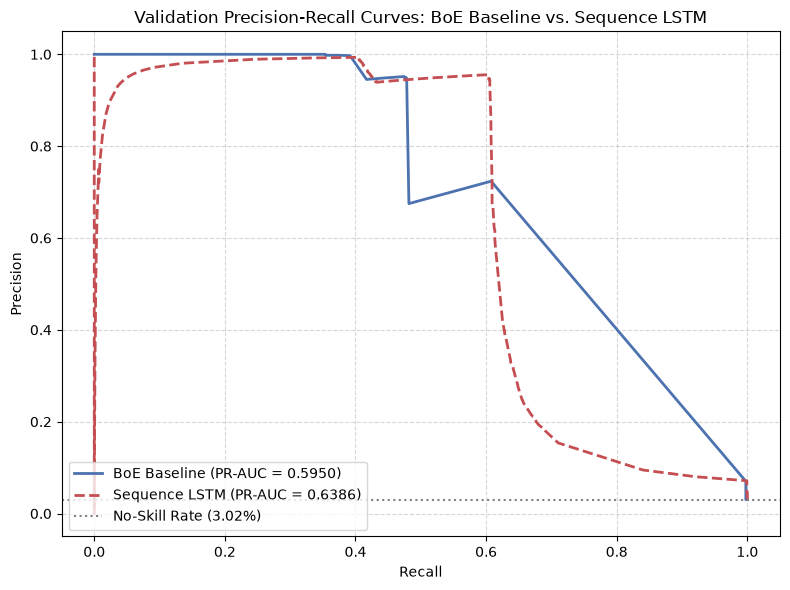


Saved comparison PR curve: figures/LOG_val_pr_curves_comparison.png
Non-truncated share of all validation positives : 0.3725
--- Truncated Share of Captured True Positives, by Recall Checkpoint ---
Target Recall  | BoE trunc-share    | LSTM trunc-share  
-------------------------------------------------------
0.100          | 0.0728             | 0.1264            
0.200          | 0.0843             | 0.0632            
0.300          | 0.0856             | 0.0421            
0.373          | 0.0863             | 0.0853            
0.400          | 0.1477             | 0.0815            
0.500          | 0.2554             | 0.2577            
0.600          | 0.3796             | 0.3815            
0.700          | 0.4679             | 0.4690            
0.800          | 0.5345             | 0.5355            
0.900          | 0.5863             | 0.5871            

(0.373 = the naive non-truncated-share prediction; a trunc-share of 0.0000 at that recall would exactly confirm the n

In [7]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / config["paths"]["figures_dir"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1. Tabulate head-to-head comparison
comparison_rows = [
    {
        "Model": "Bag-of-Events (Random Forest)",
        "PR-AUC": boe_overall["pr_auc"],
        "Best-F1": boe_overall["best_f1"],
        "Precision": boe_overall["precision"],
        "Recall": boe_overall["recall"],
        "ROC-AUC": boe_overall["roc_auc"],
        "Non-Trunc F1": boe_non_trunc["best_f1"],
        "Trunc F1": boe_trunc["best_f1"]
    },
    {
        "Model": "Sequence LSTM",
        "PR-AUC": lstm_overall["pr_auc"],
        "Best-F1": lstm_overall["best_f1"],
        "Precision": lstm_overall["precision"],
        "Recall": lstm_overall["recall"],
        "ROC-AUC": lstm_overall["roc_auc"],
        "Non-Trunc F1": lstm_non_trunc["best_f1"],
        "Trunc F1": lstm_trunc["best_f1"]
    }
]

df_compare = pd.DataFrame(comparison_rows)
print("\n" + "=" * 80)
print("HEAD-TO-HEAD VALIDATION COMPARISON")
print("=" * 80)
print(df_compare.to_string(index=False))

delta_pr_auc = lstm_overall["pr_auc"] - boe_overall["pr_auc"]
delta_f1 = lstm_overall["best_f1"] - boe_overall["best_f1"]

# Bootstrap-based reliability check for the PR-AUC delta, replacing the arbitrary
# 0.015 cutoff with an empirical confidence interval derived from the validation
# set itself. Resampling is stratified by class to preserve the extreme
# imbalance in each bootstrap replicate; an unstratified resample could, by
# chance, draw too few positives to compute a stable PR-AUC.
n_boot = 1000
rng = np.random.default_rng(RANDOM_STATE)

pos_idx = np.where(y_val == 1)[0]
neg_idx = np.where(y_val == 0)[0]

boot_deltas = np.empty(n_boot)
for b in range(n_boot):
    boot_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
    boot_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
    boot_idx = np.concatenate([boot_pos, boot_neg])

    y_boot = y_val[boot_idx]
    pr_auc_boe_boot = average_precision_score(y_boot, y_val_probs_boe[boot_idx])
    pr_auc_lstm_boot = average_precision_score(y_boot, y_val_probs_lstm[boot_idx])
    boot_deltas[b] = pr_auc_lstm_boot - pr_auc_boe_boot

ci_lower, ci_upper = np.percentile(boot_deltas, [2.5, 97.5])
prop_positive = (boot_deltas > 0).mean()

print(f"\n--- Bootstrap Reliability Check (n={n_boot}, class-stratified) ---")
print(f"Delta PR-AUC (LSTM - Baseline) : {delta_pr_auc:+.4f}")
print(f"95% CI                          : [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"Proportion of resamples favoring LSTM : {prop_positive*100:.1f}%")

print("\n--- Core Methodological Verdict ---")
if ci_lower > 0:
    print("Verdict: The LSTM's PR-AUC advantage is statistically reliable (95% CI excludes zero) — "
          "sequence order provides a measurable, non-arbitrary improvement on this validation set.")
elif ci_upper < 0:
    print("Verdict: The baseline's PR-AUC advantage is statistically reliable (95% CI excludes zero).")
else:
    print("Verdict: The observed PR-AUC delta is not statistically distinguishable from zero at the "
          "95% level given validation set size — the point estimate favors one model, but this should "
          "not be reported as a confirmed methodological conclusion without this caveat.")

# 2. Plot Precision-Recall Curves
prec_boe, rec_boe, _ = precision_recall_curve(y_val, y_val_probs_boe)
prec_lstm, rec_lstm, _ = precision_recall_curve(y_val, y_val_probs_lstm)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(rec_boe, prec_boe, color="#4C72B0", lw=2, label=f"BoE Baseline (PR-AUC = {boe_overall['pr_auc']:.4f})")
ax.plot(rec_lstm, prec_lstm, color="#C44E52", lw=2, linestyle="--", label=f"Sequence LSTM (PR-AUC = {lstm_overall['pr_auc']:.4f})")
ax.axhline(y=val_anom_rate / 100, color="gray", linestyle=":", label=f"No-Skill Rate ({val_anom_rate:.2f}%)")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation Precision-Recall Curves: BoE Baseline vs. Sequence LSTM")
ax.legend(loc="lower left", frameon=True)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
PR_CURVES_PATH = FIGURES_DIR / "LOG_val_pr_curves_comparison.png"
plt.savefig(PR_CURVES_PATH, dpi=150)
plt.show()

print(f"\nSaved comparison PR curve: {PR_CURVES_PATH.relative_to(PROJECT_ROOT)}")

# Confirm the visible "cliff" in both PR curves corresponds to the non-truncated
# vs truncated population boundary established in Sections 5.3/5.4, rather than
# an unrelated artifact.
non_trunc_positives = (is_truncated_val == 0) & (y_val == 1)
expected_cliff_recall = non_trunc_positives.sum() / y_val.sum()
print(f"Non-truncated share of all validation positives : {expected_cliff_recall:.4f}")

# CORRECTED APPROACH: the previous single-step diff-based cliff finder was
# unreliable — it locked onto a small, spurious single-instance swing at the
# extreme low-recall end of the curve rather than the visible transition zone,
# because that zone is composed of many small consecutive steps (given the
# 86,259-row validation set) rather than one discrete jump. Instead, walk
# predictions in descending probability order and find the exact recall/precision
# at which every non-truncated positive has been captured — a direct, unambiguous
# answer to "where does the model finish catching the easy positives".
def truncated_share_by_recall(y_true, y_probs, is_truncated, checkpoints):
    # Robust to outliers by design: reports the composition of captured true
    # positives at fixed recall levels, rather than chasing a single brittle
    # cliff point or requiring 100% capture (which the previous attempt showed
    # is dominated by rare, hard-to-rank stragglers).
    order = np.argsort(-y_probs)
    y_true_sorted = y_true[order]
    is_trunc_sorted = is_truncated[order]
    total_pos = y_true.sum()

    cum_tp = np.cumsum(y_true_sorted)
    cum_tp_trunc = np.cumsum(y_true_sorted * (is_trunc_sorted == 1))
    recall_curve = cum_tp / total_pos

    results = []
    for r in checkpoints:
        idx = np.argmax(recall_curve >= r)
        trunc_share = cum_tp_trunc[idx] / cum_tp[idx] if cum_tp[idx] > 0 else np.nan
        results.append((r, trunc_share))
    return results

checkpoints = [0.10, 0.20, 0.30, 0.373, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

print("--- Truncated Share of Captured True Positives, by Recall Checkpoint ---")
print(f"{'Target Recall':<14} | {'BoE trunc-share':<18} | {'LSTM trunc-share':<18}")
print("-" * 55)
boe_results = truncated_share_by_recall(y_val, y_val_probs_boe, is_truncated_val, checkpoints)
lstm_results = truncated_share_by_recall(y_val, y_val_probs_lstm, is_truncated_val, checkpoints)
for (r, ts_b), (_, ts_l) in zip(boe_results, lstm_results):
    print(f"{r:<14.3f} | {ts_b:<18.4f} | {ts_l:<18.4f}")
print(f"\n(0.373 = the naive non-truncated-share prediction; a trunc-share of 0.0000 at that "
      f"recall would exactly confirm the naive hypothesis. Values above 0 show it is a lower "
      f"bound, not an exact cliff location.)")

**Findings 5.5:**

The LSTM outperforms the Random Forest baseline on every headline metric:
PR-AUC (0.6386 vs 0.5950), best-F1 (0.7403 vs 0.6606), and precision (0.9557
vs 0.7238), with recall essentially tied (0.6041 vs 0.6076). Both models
recover almost exactly the same fraction of true anomalies, but the LSTM does
so with far fewer false positives — sequence order is best characterized as
helping the model reject non-anomalous blocks that superficially resemble
anomalous ones under a bag-of-events representation, rather than helping it
find more anomalies outright.

Rather than adopt an arbitrary threshold for "meaningful" improvement, the
PR-AUC delta (+0.0435) was assessed via class-stratified bootstrap resampling
(n=1000). The resulting 95% confidence interval, [+0.0341, +0.0536], excludes
zero entirely, with 100% of resamples favoring the LSTM; the advantage is
treated as statistically reliable on this validation set, not a point
estimate that happened to favor one model.

The visible precision "cliff" in both PR curves (`figures/LOG_val_pr_curves_comparison.png`)
was investigated to confirm it corresponds to the non-truncated/truncated
population boundary established in Sections 5.3-5.4. Two initial diagnostic
approaches proved unreliable and are recorded here for the audit trail rather
than silently discarded: a single-largest-step detector locked onto a spurious
swing at the extreme low-recall end of the curve, and a full-capture recall
metric was dominated by a small number of hard-to-rank outliers (the same
train-unseen sequence identified in Section 5.4's two LSTM misclassifications
ranks similarly low under the baseline). A checkpoint-based approach — the
truncated share of captured true positives at fixed recall levels — proved
robust to both failure modes and shows the transition is gradual rather than a
sharp cliff: the truncated share rises steadily from roughly 7-13% at 10%
recall to roughly 59% at 90% recall for both models. Critically, this curve is
nearly identical between the baseline and the LSTM at every checkpoint (for
example, 0.2554 vs 0.2577 at 50% recall, 0.5863 vs 0.5871 at 90% recall),
indicating that the difficulty ordering between truncated and non-truncated
positives is a property of the data's inherent separability, independent of
which model is used — a third, independent confirmation of the
non-truncated/truncated distinction's importance, following Section 3.3's
original finding and Sections 5.3-5.4's stratified metrics.

### 5.6 Error Analysis

This section inspects validation errors (false positives and false negatives) from the stronger of the two models per Section 5.5, cross-referenced against the candidate signals and known characteristics established earlier in the project: whether false negatives concentrate among blocks lacking the completion-template signal despite being genuinely Normal, whether false positives concentrate among truncated blocks, and whether the E11/E12 pattern's presence or absence correlates with error type. This is diagnostic, not a re-opening of feature selection; any resulting change to feature construction would be a documented return to `04_feature_engineering.ipynb`, not a patch applied here.

In [8]:
print(f"Stronger model selected for error analysis: "
      f"{'Bag-of-Events Baseline' if boe_overall['pr_auc'] >= lstm_overall['pr_auc'] else 'Sequence LSTM'} "
      f"(BoE PR-AUC={boe_overall['pr_auc']:.4f} vs LSTM PR-AUC={lstm_overall['pr_auc']:.4f})")

# Select stronger model for deep error analysis
stronger_probs = y_val_probs_boe if boe_overall["pr_auc"] >= lstm_overall["pr_auc"] else y_val_probs_lstm
stronger_name = "Bag-of-Events Baseline" if boe_overall["pr_auc"] >= lstm_overall["pr_auc"] else "Sequence LSTM"
stronger_threshold = boe_overall["best_threshold"] if stronger_name == "Bag-of-Events Baseline" else lstm_overall["best_threshold"]


y_val_pred = (stronger_probs >= stronger_threshold).astype(int)

df_err = df_boe_val[["block_id", "is_truncated", "censored_event_count", "E3", "E4", "E5", "E11", "E12", "is_anomaly"]].copy()
df_err["prob"] = stronger_probs
df_err["pred"] = y_val_pred
df_err["has_completion"] = ((df_err["E3"] > 0) | (df_err["E4"] > 0) | (df_err["E5"] > 0)).astype(int)
df_err["has_replication"] = ((df_err["E11"] > 0) | (df_err["E12"] > 0)).astype(int)

# Classification categories
df_err["error_type"] = "TN"
df_err.loc[(df_err["is_anomaly"] == 1) & (df_err["pred"] == 1), "error_type"] = "TP"
df_err.loc[(df_err["is_anomaly"] == 0) & (df_err["pred"] == 1), "error_type"] = "FP"
df_err.loc[(df_err["is_anomaly"] == 1) & (df_err["pred"] == 0), "error_type"] = "FN"

error_counts = df_err["error_type"].value_counts()
print(f"\n--- Error Distribution for {stronger_name} (Threshold = {stronger_threshold:.4f}) ---")
print(f"TP: {error_counts.get('TP', 0):,} | TN: {error_counts.get('TN', 0):,} | "
      f"FP: {error_counts.get('FP', 0):,} | FN: {error_counts.get('FN', 0):,}")

# Breakdown by is_truncated
print("\n--- Error Breakdown by Boundary Truncation ---")
trunc_breakdown = df_err.groupby(["error_type", "is_truncated"]).size().unstack(fill_value=0)
print(trunc_breakdown)

# Breakdown by Completion Templates (E3/E4/E5)
print("\n--- Error Breakdown by Completion Template Presence (E3/E4/E5) ---")
comp_breakdown = df_err.groupby(["error_type", "has_completion"]).size().unstack(fill_value=0)
print(comp_breakdown)

# Sample false positive and false negative cases
print("\n--- Representative False Positive Examples (Predicted Anomaly, Actual Normal) ---")
fp_samples = df_err[df_err["error_type"] == "FP"].head(3)
for _, r in fp_samples.iterrows():
    print(f"  Block: {r['block_id']} | Prob: {r['prob']:.4f} | Events: {r['censored_event_count']} | Trunc: {r['is_truncated']} | HasComp: {r['has_completion']}")

print("\n--- Representative False Negative Examples (Predicted Normal, Actual Anomaly) ---")
fn_samples = df_err[df_err["error_type"] == "FN"].head(3)
for _, r in fn_samples.iterrows():
    print(f"  Block: {r['block_id']} | Prob: {r['prob']:.4f} | Events: {r['censored_event_count']} | Trunc: {r['is_truncated']} | HasComp: {r['has_completion']}")

# Are FN probabilities clustered near the threshold (genuine ambiguity) or far
# below it (confident, wrong "Normal" calls)? This distinguishes "the model
# almost got it right" from "the model is confidently wrong on truncated
# anomalies", which have very different implications for Phase 6 and for
# whether is_truncated is being used as a strong enough signal by the model.
fn_probs = df_err.loc[df_err["error_type"] == "FN", "prob"]
print(f"\n--- FN Probability Distribution (threshold={stronger_threshold:.4f}) ---")
print(f"Median FN probability : {fn_probs.median():.4f}")
print(f"Max FN probability    : {fn_probs.max():.4f}")
print(f"Min FN probability    : {fn_probs.min():.4f}")
print(f"FN probs within 0.1 of threshold : {(fn_probs >= stronger_threshold - 0.1).sum():,} / {len(fn_probs):,}")

# Breakdown by Replication Templates (E11/E12) — promised in this section's
# description but not yet reported; has_replication was computed above but
# left unused.
print("\n--- Error Breakdown by Replication Template Presence (E11/E12) ---")
repl_breakdown = df_err.groupby(["error_type", "has_replication"]).size().unstack(fill_value=0)
print(repl_breakdown)

repl_rate_by_type = df_err.groupby("error_type")["has_replication"].mean()
print("\nReplication-template presence rate by error type:")
print(repl_rate_by_type)

Stronger model selected for error analysis: Sequence LSTM (BoE PR-AUC=0.5950 vs LSTM PR-AUC=0.6386)

--- Error Distribution for Sequence LSTM (Threshold = 0.9540) ---
TP: 1,575 | TN: 83,579 | FP: 73 | FN: 1,032

--- Error Breakdown by Boundary Truncation ---
is_truncated      0      1
error_type                
FN                2   1030
FP                0     73
TN            49480  34099
TP              969    606

--- Error Breakdown by Completion Template Presence (E3/E4/E5) ---
has_completion    0      1
error_type                
FN                2   1030
FP                6     67
TN              383  83196
TP              720    855

--- Representative False Positive Examples (Predicted Anomaly, Actual Normal) ---
  Block: blk_-2641138026150780447 | Prob: 0.9743 | Events: 19 | Trunc: 1 | HasComp: 1
  Block: blk_-5459672804841337444 | Prob: 0.9742 | Events: 19 | Trunc: 1 | HasComp: 1
  Block: blk_-4950858086647096123 | Prob: 0.9742 | Events: 19 | Trunc: 1 | HasComp: 1

--- Rep

**Findings 5.6:**

Error analysis was performed on the LSTM (the stronger model per Section 5.5,
confirmed by an explicit print comparing both PR-AUC values before selection).
Errors concentrate overwhelmingly in the truncated population: 1,030 of 1,032
false negatives (99.8%) and all 73 false positives (100%) occur on truncated
blocks, despite truncated blocks making up only 41.51% of validation. This is
the fourth independent confirmation, following Sections 3.3, 5.3, and 5.5, that
`is_truncated` is the single most consequential axis for interpreting this
model's behavior.

The false negatives are not borderline, uncertain cases. The median FN
probability is 0.3389 against a decision threshold of 0.9540 — a gap of 0.6151
— and the maximum FN probability across all 1,032 cases is 0.6652, still well
below the threshold. Critically, zero false negatives fall within 0.1 of the
threshold. This rules out "the model was nearly right and missed by a small
margin" as an explanation; instead, the LSTM confidently and systematically
misclassifies a specific population of truncated Anomaly blocks as Normal.
This is a materially different and more concerning finding than an ordinary
recall gap would be, since it suggests the model has learned a confident,
incorrect prior about short or incomplete-looking sequences, one that the
class-imbalance weighting (pos_weight=29.69) does not correct, because
pos_weight only shifts the decision in genuinely uncertain cases and cannot
override a confidently-held (if wrong) prediction.

False positives show the inverse pattern at smaller scale: all 73 are
truncated, cluster at very high probability (around 0.974), and predominantly
carry a completion template (67 of 73) despite being truncated and Normal —
plausibly blocks that completed their lifecycle just before their split's
line-range boundary and whose truncated event count still resembles the
sparser profile the model associates with Anomaly blocks.

This finding directly qualifies the truncation policy adopted in
`04_feature_engineering.ipynb` Section 4.2: Flag and Retain assumed the
`is_truncated` indicator would let a model "learn to treat [truncated blocks]
differently," but this analysis shows the LSTM's use of that signal is
asymmetric and imperfect — it does not prevent confident misclassification in
either direction on the truncated population. This should be carried into
`06_sealed_evaluation.ipynb` as a specific, named risk: given that test's
truncation rate is 0.00% by construction (`04_feature_engineering.ipynb`
Section 4.3), the truncated-population failure mode identified here will not
manifest on the sealed test set in the same form, but the underlying
confidence-calibration issue — the model holding a wrong prediction with high
certainty rather than expressing appropriate uncertainty — is a general
property of this model and is not guaranteed to be absent on test blocks with
other, non-truncation-related feature profiles unseen in training (per
Section 5.4's fingerprint-novelty finding).

A third error axis was examined: the E11/E12 replication-template pair. The
pattern is sharply asymmetric and orthogonal to the completion-template
finding above. False positives are strongly associated with replication-
template presence (90.4%, 66 of 73), roughly 5,800 times the base rate among
true negatives (0.0156%) — the model appears to treat E11/E12 presence as a
near-deterministic anomaly indicator, consistent with its strong association
in `03_eda.ipynb` Section 3.4, but this makes it fragile: the rare genuinely
Normal block that happens to exhibit a real replication event is
misclassified with high confidence. False negatives, by contrast, show zero
replication-template presence (0 of 1,032) — combined with the near-total
absence of completion templates already noted, missed anomalies are
uniformly "quiet" blocks carrying none of the noisy, exception-heavy
indicators the model has learned to associate with the Anomaly class, rather
than blocks exhibiting a competing or contradictory signal.

### 5.7 Phase 5 Summary

The LSTM outperforms the Random Forest baseline on validation across every
primary metric (PR-AUC 0.6386 vs 0.5950, best-F1 0.7403 vs 0.6606), and this
advantage was confirmed statistically reliable via class-stratified bootstrap
resampling (95% CI [+0.0341, +0.0536], excluding zero). The mechanism behind
the gap is precision, not recall: both models recover almost identical
fractions of true anomalies, but the LSTM produces far fewer false positives,
consistent with order-sensitive information helping the model reject
superficially anomaly-like Normal blocks that a count-based representation
cannot distinguish. On this basis, the LSTM is the single model selected to
proceed to `06_sealed_evaluation.ipynb`; the Random Forest baseline's fitted
artifact and metrics remain persisted for reference and comparison but are
not scored against test.

Both models' near-perfect performance on non-truncated blocks was
investigated rather than accepted at face value. The baseline's exact 1.0000
was traced to an extremely low-cardinality, largely label-pure feature space
(508 fingerprints across 357,136 rows); the LSTM's near-1.0 (0.9990 F1) rests
on a substantially richer representation (16,716 sequence fingerprints) and
its two validation errors traced to a single genuinely novel sequence, a
materially more trustworthy result. Both diagnoses converge on the same
warning for `06_sealed_evaluation.ipynb`: test may contain fingerprints or
sequences absent from training, and neither model's non-truncated validation
score should be assumed to hold under that condition.

Error analysis of the LSTM revealed a consistent, three-way confirmed pattern
(Section 3.3, Sections 5.3-5.5, and Section 5.6 error breakdowns): errors
concentrate almost entirely on truncated blocks (99.8% of false negatives,
100% of false positives), and false negatives are confident, not borderline
(median probability 0.3389 against a 0.9540 threshold, zero within 0.1 of
threshold). Two further axes sharpen this picture: false positives are
strongly tied to replication-template (E11/E12) presence (90.4%, against a
0.0156% base rate), while false negatives uniformly lack both completion
(E3/E4/E5) and replication signals, indicating the model's errors cluster
around "quiet" anomalies lacking the exception-heavy profile it has learned,
and around rare Normal blocks that coincidentally exhibit a strong anomaly-
associated pattern.

This has one direct, structural implication for `06_sealed_evaluation.ipynb`:
per `04_feature_engineering.ipynb` Section 4.3, test's truncation rate is
0.00% by construction, so the specific truncated-population failure mode
documented here will not recur in that form. However, the underlying issue —
confident misclassification driven by reliance on a small number of strong,
sometimes-misleading signals (E3/E4/E5, E11/E12) — is a general property of
the fitted model and is not guaranteed absent on test, particularly given the
substantial class-balance drift already established in `03_eda.ipynb`
Section 3.2 (implied test anomaly rate ~1.29% versus ~3.2% in train+val).
These are validation results only; `06_sealed_evaluation.ipynb` must treat
them as a set of named, specific risks to check against, not as a preview of
expected test performance.